In [6]:
import os

print(os.listdir("D:\\"))

['$RECYCLE.BIN', '2011 usain bolt.mp4', '20240610_111756.mp4', 'Ad Poster', 'alquizpuzzleteam.zip', 'Capacity develop', 'coop', 'DL Assignement', 'DL dataset', 'DPI', 'DumpStack.log.tmp', 'felicitation 2023.pptx', 'GTC9900', 'HealthBridge', 'Insath M', 'Islam', 'm', 'Mansoor', 'Mathematics Fever', 'Maths Singhala', 'MedInsight AI', 'Microsoft.Services.Store.winmd', 'Ministry', 'Mosque', 'Motivation', 'My projects', 'newoop', 'npm-cache', 'Online Class-1.pptx', 'Online Tutes-10 3rd term', 'Online Tutes-11 3rd term', 'OS (C) - Shortcut.lnk', 'Personal', 'Primary', 'Program Files', 'Province', 'Results analysis report.pptx', 'rtr24EE.tmp', 'System Volume Information', 'Temp', 'tmp', 'U demy', 'Vappa', 'WhatsApp Installer (2).exe', 'Wife']


In [7]:
import os

BASE_PATH = r"D:\DL Assignement"

print(os.listdir(BASE_PATH))

['aptos2019-blindness-detection', 'Deep-Learning-Assignment-Group-ID-5']


In [8]:
PROJECT_ROOT = os.path.join(
    BASE_PATH,
    "aptos2019-blindness-detection"
)


print(PROJECT_ROOT)

print(os.listdir(PROJECT_ROOT))

D:\DL Assignement\aptos2019-blindness-detection
['sample_submission.csv', 'test.csv', 'test_images', 'train.csv', 'train_images']


In [9]:
import pandas as pd


train_csv_path = os.path.join(
    PROJECT_ROOT,
    "train.csv"
)


df = pd.read_csv(train_csv_path)


print(df.head())


print("\nDataset shape:")
print(df.shape)

        id_code  diagnosis
0  000c1434d8d7          2
1  001639a390f0          4
2  0024cdab0c1e          1
3  002c21358ce6          0
4  005b95c28852          0

Dataset shape:
(3662, 2)


In [10]:
class_names = [
    "No_DR",
    "Mild",
    "Moderate",
    "Severe",
    "Proliferative_DR"
]


df["label_name"] = df["diagnosis"].map(
    {
        0:"No_DR",
        1:"Mild",
        2:"Moderate",
        3:"Severe",
        4:"Proliferative_DR"
    }
)


df.head()

,id_code,diagnosis,label_name
0,000c1434d8d7,2,Moderate
1,001639a390f0,4,Proliferative_DR
2,0024cdab0c1e,1,Mild
3,002c21358ce6,0,No_DR
4,005b95c28852,0,No_DR


In [11]:
df["label_name"].value_counts()

label_name
No_DR               1805
Moderate             999
Mild                 370
Proliferative_DR     295
Severe               193
Name: count, dtype: int64

In [12]:
import os

IMAGE_FOLDER = os.path.join(
    PROJECT_ROOT,
    "train_images"
)


df["image_path"] = df["id_code"].apply(
    lambda x: os.path.join(
        IMAGE_FOLDER,
        x + ".png"
    )
)


df.head()

,id_code,diagnosis,label_name,image_path
0,000c1434d8d7,2,Moderate,D:\DL Assignement\aptos2019-blindness-detectio...
1,001639a390f0,4,Proliferative_DR,D:\DL Assignement\aptos2019-blindness-detectio...
2,0024cdab0c1e,1,Mild,D:\DL Assignement\aptos2019-blindness-detectio...
3,002c21358ce6,0,No_DR,D:\DL Assignement\aptos2019-blindness-detectio...
4,005b95c28852,0,No_DR,D:\DL Assignement\aptos2019-blindness-detectio...


In [13]:
from sklearn.model_selection import train_test_split


train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["diagnosis"],
    random_state=42
)


print("Training images:", len(train_df))
print("Validation images:", len(val_df))


print("\nTraining distribution:")
print(train_df["label_name"].value_counts())


print("\nValidation distribution:")
print(val_df["label_name"].value_counts())

Training images: 2929
Validation images: 733

Training distribution:
label_name
No_DR               1444
Moderate             799
Mild                 296
Proliferative_DR     236
Severe               154
Name: count, dtype: int64

Validation distribution:
label_name
No_DR               361
Moderate            200
Mild                 74
Proliferative_DR     59
Severe               39
Name: count, dtype: int64


In [14]:
import tensorflow as tf


IMG_SIZE = (224,224)
BATCH_SIZE = 32


def load_image(path, label):

    image = tf.io.read_file(path)

    image = tf.image.decode_png(
        image,
        channels=3
    )

    image = tf.image.resize(
        image,
        IMG_SIZE
    )

    image = tf.keras.applications.efficientnet.preprocess_input(
        image
    )

    return image, label



# Convert labels

train_paths = train_df["image_path"].values
train_labels = train_df["diagnosis"].values


val_paths = val_df["image_path"].values
val_labels = val_df["diagnosis"].values



# Create datasets

train_dataset = tf.data.Dataset.from_tensor_slices(
    (
        train_paths,
        train_labels
    )
)


val_dataset = tf.data.Dataset.from_tensor_slices(
    (
        val_paths,
        val_labels
    )
)



train_dataset = train_dataset.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)


val_dataset = val_dataset.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)



train_dataset = train_dataset.shuffle(1000).batch(
    BATCH_SIZE
).prefetch(tf.data.AUTOTUNE)



val_dataset = val_dataset.batch(
    BATCH_SIZE
).prefetch(tf.data.AUTOTUNE)



print("Dataset created successfully")

Dataset created successfully


In [15]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight


# Get training labels

y_train = train_df["diagnosis"].values


# Calculate balanced weights

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)


# Convert to dictionary

class_weights = dict(
    enumerate(class_weights_array)
)


print(class_weights)

{0: np.float64(0.4056786703601108), 1: np.float64(1.979054054054054), 2: np.float64(0.7331664580725907), 3: np.float64(3.803896103896104), 4: np.float64(2.4822033898305085)}


In [17]:
from model.efficientnetb0 import create_efficientnetb0


model = create_efficientnetb0()


model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,055,976 (15.47 MB)

 Trainable params: 1,357,365 (5.18 MB)

 Non-trainable params: 2,698,611 (10.29 MB)

In [18]:
from tensorflow.keras.optimizers import Adam


model.compile(

    optimizer=Adam(
        learning_rate=0.0001
    ),

    loss="sparse_categorical_crossentropy",

    metrics=[
        "accuracy"
    ]

)


print("Model compiled successfully")

Model compiled successfully


In [19]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)


callbacks = [

    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),


    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=3,
        min_lr=1e-7
    ),


    ModelCheckpoint(
        "best_efficientnetb0.keras",
        monitor="val_accuracy",
        save_best_only=True
    )

]


print("Callbacks created")

Callbacks created


In [20]:
EPOCHS = 30


history = model.fit(

    train_dataset,

    validation_data=val_dataset,

    epochs=EPOCHS,

    class_weight=class_weights,

    callbacks=callbacks

)

Epoch 1/30


d:\DL Assignement\Deep-Learning-Assignment-Group-ID-5\venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


92/92 ━━━━━━━━━━━━━━━━━━━━ 171s 2s/step - accuracy: 0.5244 - loss: 1.3575 - val_accuracy: 0.6562 - val_loss: 0.9074 - learning_rate: 1.0000e-04
Epoch 2/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 149s 1s/step - accuracy: 0.6931 - loss: 1.0107 - val_accuracy: 0.7176 - val_loss: 0.7886 - learning_rate: 1.0000e-04
Epoch 3/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 149s 1s/step - accuracy: 0.7419 - loss: 0.8743 - val_accuracy: 0.7340 - val_loss: 0.7171 - learning_rate: 1.0000e-04
Epoch 4/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 155s 1s/step - accuracy: 0.7648 - loss: 0.7966 - val_accuracy: 0.7544 - val_loss: 0.6677 - learning_rate: 1.0000e-04
Epoch 5/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 160s 2s/step - accuracy: 0.7945 - loss: 0.7154 - val_accuracy: 0.7531 - val_loss: 0.6660 - learning_rate: 1.0000e-04
Epoch 6/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 173s 2s/step - accuracy: 0.8071 - loss: 0.6706 - val_accuracy: 0.7626 - val_loss: 0.6422 - learning_rate: 1.0000e-04
Epoch 7/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 154s 1s/step - accuracy: 0.8371 - loss: 0.6

In [22]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np


# Get predictions

y_true = []
y_pred = []


for images, labels in val_dataset:

    predictions = model.predict(images)

    predicted_classes = np.argmax(
        predictions,
        axis=1
    )

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_classes)



# Convert to numpy

y_true = np.array(y_true)
y_pred = np.array(y_pred)



# Class names

class_names = [
    "No_DR",
    "Mild",
    "Moderate",
    "Proliferative_DR",
    "Severe"
]



print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 949ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 825ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 865ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 962ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 901ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 880ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 707ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 737ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
                  precision    recall  f1-score   support

           No_DR       0.97      0.96      0.97       361
            Mild       0.50    

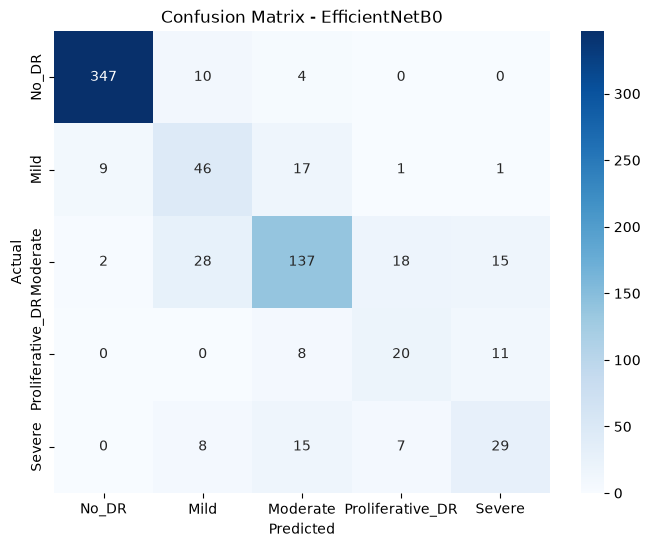

In [23]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


cm = confusion_matrix(
    y_true,
    y_pred
)


plt.figure(figsize=(8,6))


sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)


plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - EfficientNetB0")


plt.show()

In [24]:
import os

MODEL_DIR = os.path.join(
    PROJECT_ROOT,
    "results"
)

# Create results folder if not exists
os.makedirs(MODEL_DIR, exist_ok=True)


MODEL_PATH = os.path.join(
    MODEL_DIR,
    "best_efficientnetb0.keras"
)


# Save trained model
model.save(MODEL_PATH)


print("Model saved successfully!")
print(MODEL_PATH)

Model saved successfully!
D:\DL Assignement\aptos2019-blindness-detection\results\best_efficientnetb0.keras


In [25]:
import os

print(os.path.exists(MODEL_PATH))

True


In [26]:
import os

MODEL_PATH = os.path.join(
    PROJECT_ROOT,
    "results",
    "best_efficientnetb0.keras"
)

print(MODEL_PATH)
print(os.path.exists(MODEL_PATH))

D:\DL Assignement\aptos2019-blindness-detection\results\best_efficientnetb0.keras
True


In [27]:
import os
import datetime

print(
    datetime.datetime.fromtimestamp(
        os.path.getmtime(MODEL_PATH)
    )
)

2026-09-27 23:41:36.698234
